In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
import seaborn as sns
import pandas as pd

# Seed for reproducibility
np.random.seed(42)

Dataset: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps?resource=download

Strategy: Training data constains multivariate time series, where each engine is run until a fault occurs. Therefore the target ouput in the training set is the difference between the last cycle and the timesteps.

In [5]:
dataset_path = "datasets"

# Number of sensors in the dataset
NUM_SENSORS = 21

# Column names for the dataframe
columns = ["engine_id", "cycle", "op_1", "op_2", "op_3", *[f"sensor_{i}" for i in range(1,NUM_SENSORS+1)]]

# Creating dataframes
# rul_df is the ground truth of the test_df:
#   - rul[0] is the RUL for the last timestep for engine_0
train_df = pd.read_csv(f"{dataset_path}/Train/train_FD001.txt",sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv(f"{dataset_path}/Test/test_FD001.txt", sep=r"\s+", header=None, names=columns)
rul_df = pd.read_csv(f"{dataset_path}/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

# Size of the datasets.
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"RUL shape: {rul_df.shape}")


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


By looking at the head and tail of the dataframe, we can extract the following:
1. There are 100 engines run to fault.
2. We need to prune variables, as there might be varaibles that are constant, i.e they did not contribute to the fault or degradation in RUL.
3. There variables that are magnitudes larger than others:
    - We need to normalize the column values to bring them to a comparable scale. This avoid models to fit too closely to dominant variables.

In [6]:
# Displaying the first 5 rows
train_df.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
# Displaying the last 5 rows
train_df.tail()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [8]:
# Checking for NAN values in the dataset
print("NAN in Train:", train_df.isnull().sum().sum())
print("NAN in Test:", test_df.isnull().sum().sum())

NAN in Train: 0
NAN in Test: 0


In [9]:
# Checking for constant, or near constant, variables.
# The following columns can be removed:
#   - op_1-op_3, sensor_1, sensor_10,sensor_18 and sensor_19

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [10]:
# Removing columns that are constant, or near constant
columns = ["op_1", "op_2", "op_3", "sensor_1", "sensor_10","sensor_18", "sensor_19"]

for column in columns:
    train_df = train_df.drop(columns = [f"{column}"])
    test_df = test_df.drop(columns = [f"{column}"])

train_df.head()

,engine_id,cycle,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,1,1,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190
1,1,2,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236
2,1,3,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442
3,1,4,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739
4,1,5,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044


Adding target variable RUL, for each engine, in the training data. It will be calculated using this formula: 

\begin{equation}
RUL = \text{last\_cycle - current\_cycle}
\end{equation}

In addition to this, RUL will saturated to 150 to avoid prediciting large RUL values during training. It is more critical to correctly predict RUL when we are closer to failure, for maintance reasons, than predicing when a maintance is in the far distance.

In [11]:
RUL = []
for row_index in range(len(train_df)):
    current_cycle = train_df.iloc[row_index]["cycle"] # Current cycle of the engine
    engine_id = train_df.iloc[row_index]["engine_id"] # Engine_id
    last_cycle = len(train_df[train_df["engine_id"] == engine_id]) # Extracts the last cycle value for the engine
    cycles_remaning = last_cycle-current_cycle

    # RUL saturates to 150 
    if cycles_remaning > 150:
        cycles_remaning = 150

    RUL.append(cycles_remaning) # RUL at each cycle

# Adding RUL to the training set
train_df.insert(2, "RUL", RUL)

Normalizing the variables, except engine_id, cycles, and RUL as they are not inputs to the system

In [12]:
columns_to_normalize = [column for column in train_df.columns if column not in ["engine_id", "cycle", "RUL"]]
scaler = StandardScaler()

train_df[columns_to_normalize] = scaler.fit_transform(train_df[columns_to_normalize])
test_df[columns_to_normalize] = scaler.transform(test_df[columns_to_normalize])

In [13]:
train_df.head()

,engine_id,cycle,RUL,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,1,1,150.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,1.348493,1.194427
1,1,2,150.0,-1.061780,0.211528,-0.643726,-1.776357e-15,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,1.016528,1.236922
2,1,3,150.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.739891,0.503423
3,1,4,150.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.352598,0.777792
4,1,5,150.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.463253,1.059552


In the C-MAPSS dataset challenge, we are given the RUL for the last recorded cycle. Therefore the test data is the last row for each engine in the test_df with the corresponding RUL in the RUL_df.

In [14]:
X_train = train_df[columns_to_normalize]
y_train = train_df["RUL"]

X_test = test_df.groupby("engine_id").last().reset_index() # Extracts the last row for each engine
X_test = X_test[columns_to_normalize] # Extracting only the inputs to the model
y_test = rul_df["RUL"] # RUL value for the last cycle in the train_df


print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_test.shape}")

Training Data: X=(20631, 17), y=(20631,)
Testing Data:  X=(100, 17),  y=(100,)


#### Modeling
We will train and evaluate different models to find the best performer for the dataset:
* **Linear Regression**: Ordinary Least Squares and Ridge regression
* **Support Vector Regressor**
* **Random Forest Regressor**

Evaluation Metrics: 
* **Root Mean Squared Error**: Gives us the number of cycles are we off
* **R2 score**: How well the model explains the variance in RUL

In [15]:
# Empty list that will contain a dictionary of each model"s performance
results = []

# 
def evaluation(model, model_name, X_train, y_train, X_test, y_test, hyperparameter_tuning = False):
    model.fit(X_train,y_train) # Training the model
    predictions = model.predict(X_test) # Model predictions

    RMSE = np.sqrt(mean_squared_error(y_test, predictions))
    R2 = r2_score(y_test, predictions)

    # To prevent generating plots when tuning hyperparameters
    if not hyperparameter_tuning:
        results.append({
            "Model": model_name,
            "RMSE": RMSE,
            "R2":R2})
        
        # Plot Predictions
        plt.figure(figsize=(10, 3))
        plt.plot(y_test.values, label="Actual RUL", linestyle="--")
        plt.plot(predictions, label=f"Predicted RUL ({model_name})")
        plt.xlabel("Engine_id")
        plt.ylabel("Remaining Useful Life (RUL)")
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"{model_name} Performance")
        print(f"RMSE: {RMSE:.2f}")
        print(f"R2:   {R2:.2%}")

        return
    return RMSE, R2


### Ordinary Least Squares

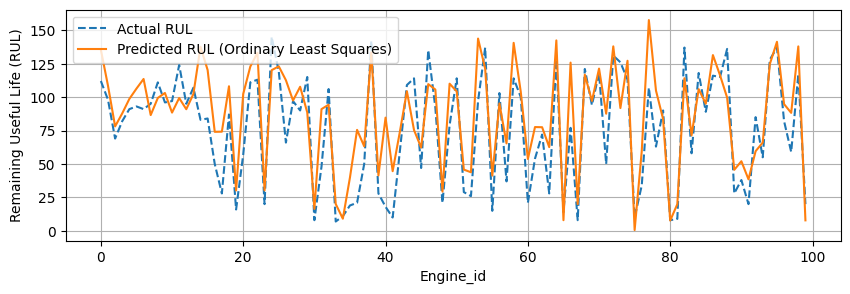

Ordinary Least Squares Performance
RMSE: 23.88
R2:   66.99%


In [16]:
OLS = LinearRegression()
evaluation(OLS, "Ordinary Least Squares", X_train, y_train, X_test, y_test)

### Ridge Regression
Hyperparameter the regularization strength.

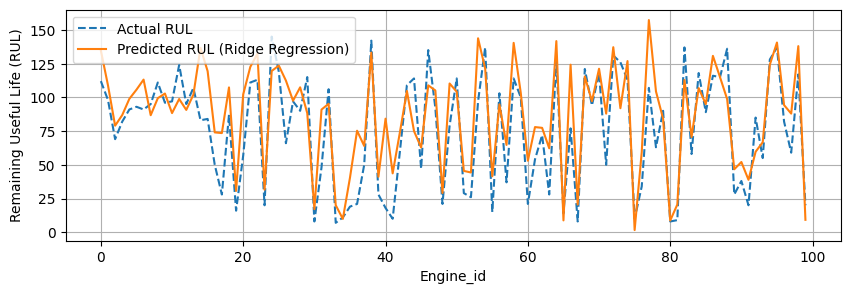

Ridge Regression Performance
RMSE: 23.75
R2:   67.32%


In [ ]:
# Evaluation metrics
model_RMSE = 10e6 # Initial value for comparison
model_R2 = 0

# Hyperparameter
regularization_strengths = np.logspace(-3, 3, 100) 

# Final model parameter
model_alpha = 0

for alpha in regularization_strengths:
    Ridge_regression = Ridge(alpha) # Creating the model
    RMSE, R2 = evaluation(Ridge_regression, "Ridge Regression", X_train, y_train, X_test, y_test, True) # Training and evaluating the model

    # Saving the best performing hyperparameter (in terms of RMSE), and it's RMSE and R2 score
    if RMSE < model_RMSE:
        model_RMSE = RMSE
        model_alpha = alpha
        model_R2 = R2

Ridge_regression = Ridge(model_alpha) 
evaluation(Ridge_regression, "Ridge Regression", X_train, y_train, X_test, y_test)

### Support Vector Regressor

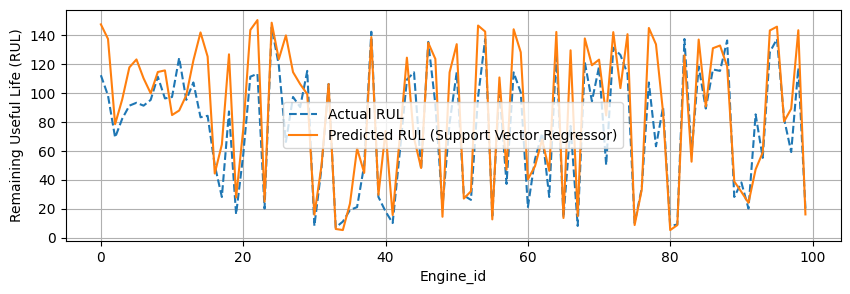

Support Vector Regressor Performance
RMSE: 23.84
R2:   67.08%


In [19]:
SupportVectorRegressor =  SVR(kernel="rbf")
evaluation(SupportVectorRegressor, "Support Vector Regressor", X_train, y_train, X_test, y_test)

### Random Forest Regressor
Hyperparameter tuning n_estimators and max_depth. To find the optimal hyperparameter, we will first use a course grid search to find intervals with potential optimal values, these intervals will be used in a finer grid search.

In [ ]:
# Evaluation metrics
model_RMSE = 10e6 # Initial value for comparison
model_R2 = 0

# Hyperparameters
hp_n_estimators = [50, 100, 200, 300, 500] 
hp_max_depths = [3, 5, 8, 12, 20, 25, 50] 

# Results for plotting heatmaps
rmse_results = np.zeros((len(hp_n_estimators), len(hp_max_depths))) 
R2_results = np.zeros((len(hp_n_estimators), len(hp_max_depths))) 

# Final parameters
model_n_estimators = 0 
model_max_depth = 0

for i, n_estimators in enumerate(hp_n_estimators):
    for j, max_depth in enumerate(hp_max_depths):  
        RandomForest = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1) # Creating the model
        RMSE, R2 = evaluation(RandomForest, "Random Forest Regressor", X_train, y_train, X_test, y_test, True) # Training and evaluation the model 

        rmse_results[i, j] = RMSE # Storing the results in the heatmap grid
        R2_results[i, j] = R2 # Storing the results in the heatmap grid

        # Saving the best performing hyperparameters (in terms of RMSE), and it's RMSE and R2 score
        if RMSE < model_RMSE:
            model_RMSE = RMSE
            model_R2 = R2
            model_n_estimators = n_estimators
            model_max_depth = max_depth

#### Heatmaps for the RMSE and R2 wrt the hyperparameters

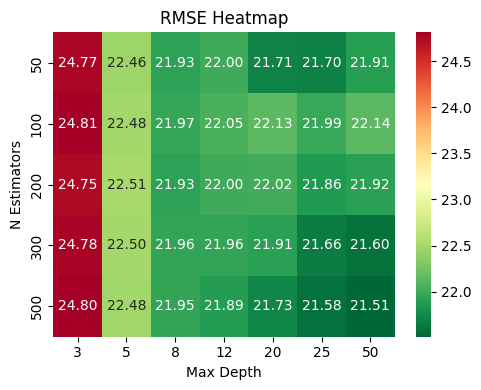

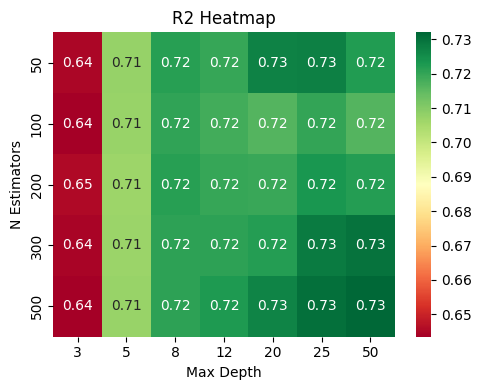

In [21]:
# Heatmaps
plt.figure(figsize=(5, 4))
sns.heatmap(
    rmse_results,
    annot=True,
    fmt=".2f",
    xticklabels=hp_max_depths,
    yticklabels=hp_n_estimators,
    cmap="RdYlGn_r"
)
plt.xlabel("Max Depth")
plt.ylabel("N Estimators")
plt.title("RMSE Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(
    R2_results,
    annot=True,
    fmt=".2f",
    xticklabels=hp_max_depths,
    yticklabels=hp_n_estimators,
    cmap="RdYlGn"
)
plt.xlabel("Max Depth")
plt.ylabel("N Estimators")
plt.title("R2 Heatmap")
plt.tight_layout()
plt.show()

Fine course grid search.

In [ ]:
# Evaluation metrics
model_RMSE = 10e6 # Initial value for comparison
model_R2 = 0

# Hyperparameters
hp_n_estimators = [300, 350, 400, 450, 500] 
hp_max_depths = [25, 30, 35, 40, 45, 50] 

# Results for plotting heatmaps
rmse_results = np.zeros((len(hp_n_estimators), len(hp_max_depths))) 
R2_results = np.zeros((len(hp_n_estimators), len(hp_max_depths))) 

# Final parameters
model_n_estimators = 0 
model_max_depth = 0

for i, n_estimators in enumerate(hp_n_estimators):
    for j, max_depth in enumerate(hp_max_depths):  
        RandomForest = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1) # Creating the model
        RMSE, R2 = evaluation(RandomForest, "Random Forest Regressor", X_train, y_train, X_test, y_test, True) # Training and evaluation the model

        rmse_results[i, j] = RMSE # Storing the results in the heatmap grid
        R2_results[i, j] = R2 # Storing the results in the heatmap grid

        # Saving the best performing hyperparameters (in terms of RMSE), and it's RMSE and R2 score
        if RMSE < model_RMSE:
            model_RMSE = RMSE
            model_R2 = R2
            model_n_estimators = n_estimators
            model_max_depth = max_depth

#### Heatmaps

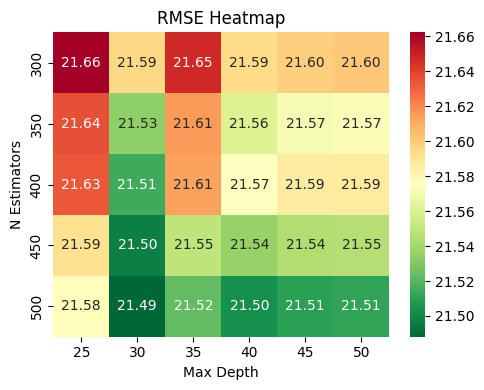

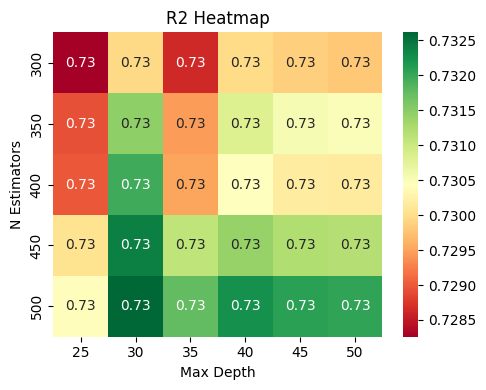

In [23]:
# Heatmaps
plt.figure(figsize=(5, 4))
sns.heatmap(
    rmse_results,
    annot=True,
    fmt=".2f",
    xticklabels=hp_max_depths,
    yticklabels=hp_n_estimators,
    cmap="RdYlGn_r"
)
plt.xlabel("Max Depth")
plt.ylabel("N Estimators")
plt.title("RMSE Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(
    R2_results,
    annot=True,
    fmt=".2f",
    xticklabels=hp_max_depths,
    yticklabels=hp_n_estimators,
    cmap="RdYlGn"
)
plt.xlabel("Max Depth")
plt.ylabel("N Estimators")
plt.title("R2 Heatmap")
plt.tight_layout()
plt.show()

Final Random Forest model

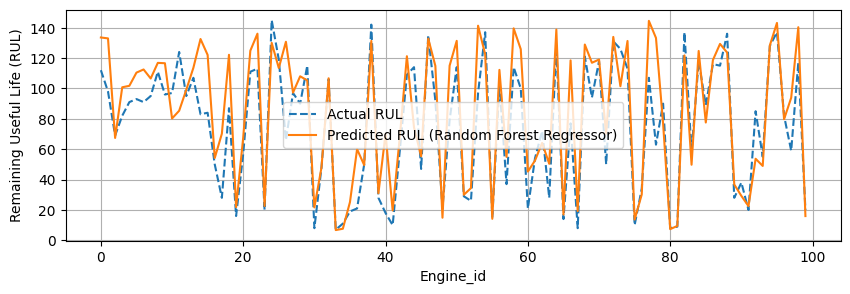

Random Forest Regressor Performance
RMSE: 21.49
R2:   73.26%


In [24]:
RandomForest = RandomForestRegressor(n_estimators=model_n_estimators, max_depth=model_max_depth, random_state=42, n_jobs=-1) # Creating the model
evaluation(RandomForest, "Random Forest Regressor", X_train, y_train, X_test, y_test) # Training and evaluating model

### Plotting comparison graph

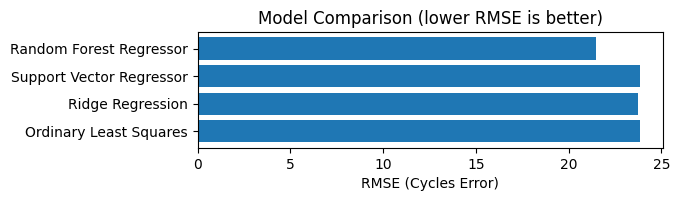

In [25]:
models = [item["Model"] for item in results]
RMSE = [item["RMSE"] for item in results]

plt.figure(figsize =(6,1.5))
plt.barh(models, RMSE)
plt.xlabel("RMSE (Cycles Error)")
plt.title("Model Comparison (lower RMSE is better)")
plt.show()

#### "Digital Twin" Simulation 

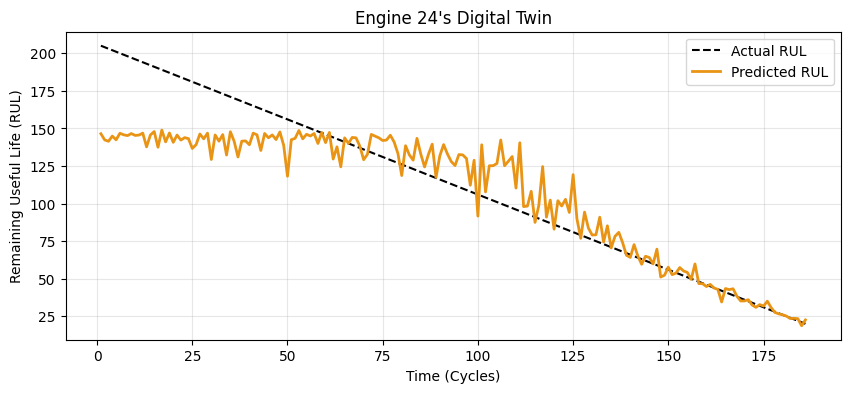

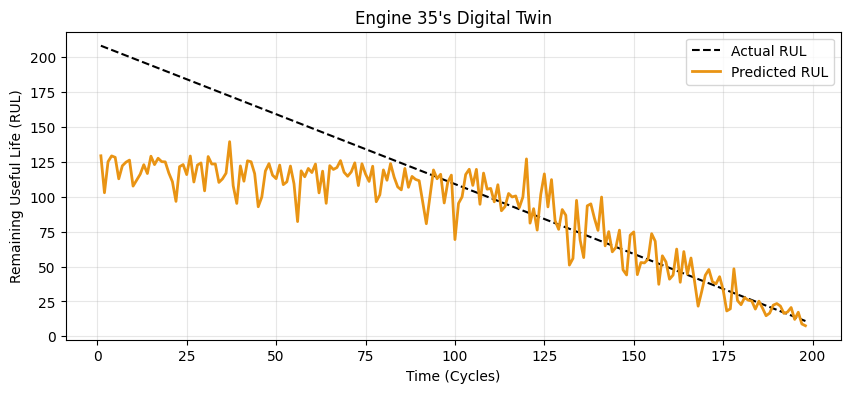

In [26]:
def digital_twin(engine_id):
        engine_df = test_df[test_df["engine_id"] == engine_id].copy()
        engine_input = engine_df[columns_to_normalize] 
        predicted_RUL = RandomForest.predict(engine_input[RandomForest.feature_names_in_.tolist()])
        
        # Calculating the actual RUL's trajectory backwards from the last known RUL in the RUL dataset
        actual_RUL = rul_df.iloc[engine_id - 1]["RUL"] # Engine_id starts at index 0, therefore we need to subtract 1 from the id
        number_of_cycles = engine_df["cycle"].max() # Number of cycles for the engine in the test 
        rul_trajectory = [] # Empty list for plotting the true RUL trajectory
        current_RUL = actual_RUL + number_of_cycles

        for _ in range(len(engine_df)):
                current_RUL -= 1
                rul_trajectory.append(current_RUL)

        # Plotting predicted RUL for a single engine, alongside the true RUL values
        plt.figure(figsize=(10, 4))
        plt.plot(engine_df["cycle"], rul_trajectory, color='black', linestyle='--', label="Actual RUL")
        plt.plot(engine_df["cycle"], predicted_RUL, color="#e99414", linewidth=2, label="Predicted RUL")
        plt.title(f"Engine {engine_id}'s Digital Twin")
        plt.xlabel("Time (Cycles)")
        plt.ylabel("Remaining Useful Life (RUL)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

digital_twin(24)
digital_twin(35)
